# PyANNOW v2.0.0 — Pattern Recognition for Chopin and Worm Dance

This notebook reframes the project from a **pattern recognition** perspective.

Two questions drive the design:

1. **What are the most excitable patterns in Chopin's piece?**
2. **How can the worm dance with those patterns using its own neural architecture?**

Best approach available for this setting: treat the MIDI score as a symbolic time series, mine salient local windows, cluster them into a compact motif bank, and export that bank as a portable archive that can be handed to a worm controller.

That is the right trade-off here because the piece is fixed. We do not need a general music generator first; we need a strong pattern extractor and a clean bridge from score patterns to worm control signals.

## Outputs

- A ranked list of the most excitable Chopin patterns.
- A motif bank saved to disk for reuse.
- A worm-dance manifest that maps score patterns to neural control channels.
- A big-picture diagram showing input, features, maps, and outputs across the pipeline.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def find_repo_root(start=None):
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / 'PyANNOW').is_dir() and (candidate / 'shared').is_dir():
            return candidate
    import pyannow as _pw
    return Path(_pw.__file__).resolve().parent.parent.parent.parent

REPO_ROOT = find_repo_root()
sys.path.insert(0, str((REPO_ROOT / 'PyANNOW').resolve()))

from chopin_score_net.data import build_score_dataset

MIDI_PATH = REPO_ROOT / 'shared' / 'examples' / 'chopin_nocturne_op_posth_csharp_minor.mid'
OUTDIR = REPO_ROOT / 'PyANNOW' / 'notebooks' / 'step_outputs' / 'v2_patterns'
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': 0.3})
print('REPO_ROOT =', REPO_ROOT)
print('OUTDIR    =', OUTDIR)

REPO_ROOT = /Users/vghayoomie/git/wormuse
OUTDIR    = /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns


## 1. Find the most excitable patterns

We use a sliding-window symbolic analysis on the Chopin piano-roll. Each window is described by a small feature vector:

- active pitch count
- onset rate
- pitch-span
- pitch-class entropy
- transition energy
- pitch-centre drift

The best available practical approach for a single fixed piece is to rank windows by a saliency score built from these features, then cluster the top windows into a motif bank. That gives both interpretability and a compact representation that can be reused later by the worm controller.

Top excitable Chopin windows:
#01  200.60s → 202.58s  saliency=+3.484  onset_rate=16.50/s  span=47  entropy=4.10
#02  200.70s → 202.68s  saliency=+3.463  onset_rate=16.50/s  span=47  entropy=4.10
#03  200.50s → 202.48s  saliency=+3.463  onset_rate=16.50/s  span=47  entropy=4.13
#04  200.80s → 202.78s  saliency=+3.414  onset_rate=16.50/s  span=47  entropy=4.13
#05  200.40s → 202.38s  saliency=+3.386  onset_rate=17.00/s  span=47  entropy=4.17
#06  200.90s → 202.88s  saliency=+3.322  onset_rate=16.50/s  span=47  entropy=4.17
#07  200.30s → 202.28s  saliency=+3.268  onset_rate=16.00/s  span=47  entropy=4.16
#08  201.00s → 202.98s  saliency=+3.175  onset_rate=15.50/s  span=47  entropy=4.16
#09  200.20s → 202.18s  saliency=+3.109  onset_rate=15.00/s  span=47  entropy=4.14
#10  201.10s → 203.08s  saliency=+3.000  onset_rate=14.50/s  span=47  entropy=4.15
#11  200.10s → 202.08s  saliency=+2.907  onset_rate=14.00/s  span=47  entropy=4.12
#12  201.20s → 203.18s  saliency=+2.794  onset_rate=13.50

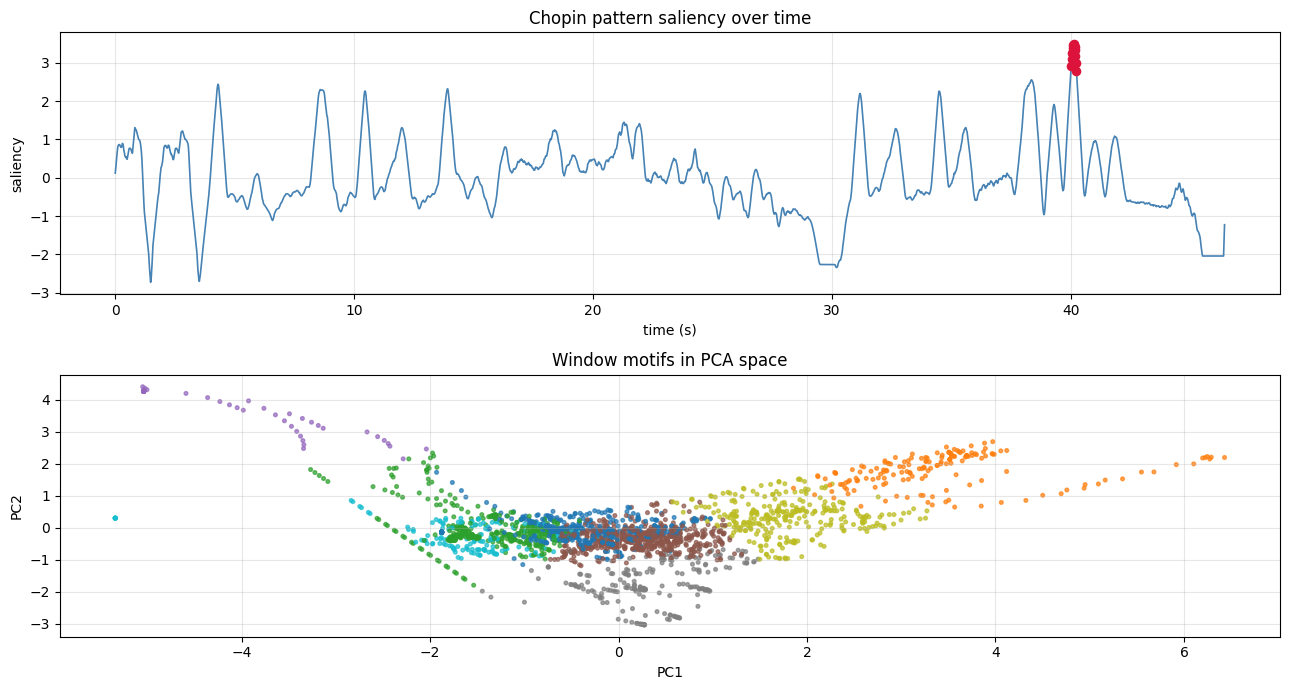

Motif representatives:
motif 1: 88.00s–89.98s  saliency=+0.277
motif 2: 200.60s–202.58s  saliency=+3.484
motif 3: 134.50s–136.48s  saliency=+0.103
motif 4: 145.70s–147.68s  saliency=-1.172
motif 5: 81.60s–83.58s  saliency=+0.804
motif 6: 4.10s–6.08s  saliency=+1.307
motif 7: 196.80s–198.78s  saliency=+1.714
motif 8: 133.70s–135.68s  saliency=+0.091


In [2]:
dataset = build_score_dataset(MIDI_PATH, resolution_s=0.02, n_harmonics=12)
roll = dataset.target_roll.astype(float)
times = dataset.times
pitches = np.asarray(dataset.pitches)
dt = float(times[1] - times[0])

def shannon_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())

def build_pattern_bank(roll, times, win_s=2.0, hop_s=0.10):
    win_bins = max(1, int(round(win_s / dt)))
    hop_bins = max(1, int(round(hop_s / dt)))
    onsets = np.vstack([np.zeros((1, roll.shape[1])), np.clip(np.diff(roll, axis=0), 0, None)])
    rows = []
    windows = []
    for start in range(0, len(roll) - win_bins + 1, hop_bins):
        stop = start + win_bins
        seg = roll[start:stop]
        seg_on = onsets[start:stop]
        pitch_activity = seg.sum(axis=0)
        active_idx = np.flatnonzero(pitch_activity > 0)
        pitch_span = int(active_idx[-1] - active_idx[0] + 1) if len(active_idx) else 0
        onset_rate = float(seg_on.sum() / win_s)
        active_mean = float(seg.sum(axis=1).mean())
        transition_energy = float(np.abs(np.diff(seg, axis=0)).sum())
        pitch_entropy = shannon_entropy(pitch_activity)
        pitch_center = float(np.average(np.arange(len(pitches)), weights=pitch_activity)) if pitch_activity.sum() else 0.0
        rows.append([active_mean, onset_rate, pitch_span, pitch_entropy, transition_energy, pitch_center])
        windows.append((start, stop))
    return np.asarray(rows, dtype=float), np.asarray(windows, dtype=int)

feature_names = [
    'active_mean',
    'onset_rate',
    'pitch_span',
    'pitch_entropy',
    'transition_energy',
    'pitch_center',
]

X_pat, windows = build_pattern_bank(roll, times, win_s=2.0, hop_s=0.10)
Xz = StandardScaler().fit_transform(X_pat)

# Saliency is a weighted combination of sparse, bursty, and harmonically varied windows.
saliency = (
    1.3 * Xz[:, 1] +
    1.0 * Xz[:, 0] +
    0.8 * Xz[:, 3] +
    0.7 * Xz[:, 4] -
    0.4 * Xz[:, 2]
)
saliency = (saliency - saliency.mean()) / (saliency.std() + 1e-8)
saliency_smooth = np.convolve(saliency, np.ones(5) / 5.0, mode='same')
top_idx = np.argsort(saliency_smooth)[-12:][::-1]

summary_rows = []
for rank, idx in enumerate(top_idx, 1):
    start, stop = windows[idx]
    summary_rows.append({
        'rank': rank,
        'start_s': float(times[start]),
        'end_s': float(times[min(stop - 1, len(times) - 1)]),
        'saliency': float(saliency_smooth[idx]),
        'active_mean': float(X_pat[idx, 0]),
        'onset_rate': float(X_pat[idx, 1]),
        'pitch_span': int(X_pat[idx, 2]),
        'pitch_entropy': float(X_pat[idx, 3]),
        'transition_energy': float(X_pat[idx, 4]),
        'pitch_center': float(X_pat[idx, 5]),
    })

print('Top excitable Chopin windows:')
for row in summary_rows:
    print(
        f"#{row['rank']:02d}  {row['start_s']:6.2f}s → {row['end_s']:6.2f}s  "
        f"saliency={row['saliency']:+.3f}  onset_rate={row['onset_rate']:.2f}/s  "
        f"span={row['pitch_span']:2d}  entropy={row['pitch_entropy']:.2f}"
    )

# Motif clustering on the full set of windows, not only the top ones.
pca = PCA(n_components=3, random_state=0)
coords = pca.fit_transform(Xz)
n_motifs = min(8, max(3, len(coords) // 90))
kmeans = KMeans(n_clusters=n_motifs, n_init=20, random_state=0)
motif_labels = kmeans.fit_predict(coords)
motif_centers = kmeans.cluster_centers_

motif_reps = []
for motif_id in range(n_motifs):
    mask = motif_labels == motif_id
    motif_scores = saliency_smooth[mask]
    motif_indices = np.flatnonzero(mask)
    rep_idx = int(motif_indices[np.argmax(motif_scores)])
    motif_reps.append(rep_idx)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(times[:len(saliency_smooth)], saliency_smooth, lw=1.2, color='steelblue')
axes[0].scatter(times[top_idx], saliency_smooth[top_idx], color='crimson', s=35, zorder=3)
axes[0].set(title='Chopin pattern saliency over time', xlabel='time (s)', ylabel='saliency')

axes[1].scatter(coords[:, 0], coords[:, 1], c=motif_labels, cmap='tab10', s=7, alpha=0.7)
axes[1].set(title='Window motifs in PCA space', xlabel='PC1', ylabel='PC2')
plt.tight_layout()
plt.show()

rep_text = []
for motif_id, rep_idx in enumerate(motif_reps, 1):
    start, stop = windows[rep_idx]
    rep_text.append(f'motif {motif_id}: {times[start]:.2f}s–{times[stop-1]:.2f}s  saliency={saliency_smooth[rep_idx]:+.3f}')
print('Motif representatives:')
print('\n'.join(rep_text))

## 2. Give the worm a dance archive

The worm does not need the whole symbolic score. It needs a compact archive:

- a motif bank with window features and representative patterns
- a manifest that records the score-side feature definition
- a worm-side neural architecture specification
- a mapping from each motif to worm control channels

This is the bridge that lets the worm 'dance' with the score patterns. The archive is portable: the motif bank can be loaded later, and the neural controller can turn each motif into a burst of command, motor, and muscle activity.

In [3]:
archive_dir = OUTDIR / 'dance_archive'
archive_dir.mkdir(parents=True, exist_ok=True)
pattern_bank_path = archive_dir / 'chopin_pattern_bank.npz'
manifest_path = archive_dir / 'worm_dance_manifest.json'

# Portable score-side archive
np.savez_compressed(
    pattern_bank_path,
    window_bounds=windows,
    window_features=X_pat,
    window_features_z=Xz,
    saliency=saliency_smooth,
    motif_labels=motif_labels,
    motif_centers=motif_centers,
    motif_representatives=np.asarray(motif_reps, dtype=int),
    times=times,
    pitches=pitches,
)

worm_arch = {
    'name': 'worm_dance_mlp',
    'hidden_layers': [12, 57, 96, 57, 12],
    'role': 'motif-conditioned control policy',
    'inputs': [
        'motif_id',
        'saliency',
        'active_mean',
        'onset_rate',
        'pitch_span',
        'pitch_entropy',
        'transition_energy',
        'pitch_center',
    ],
    'outputs': [
        'command_gain',
        'motor_gain',
        'muscle_gain',
        'phase_shift',
        'refractory_bias',
    ],
}

mapping = {
    'motif_to_control': 'saliency-driven affine map from motif features to worm gains',
    'motif_to_phase': 'excitable motifs advance phase; sparse motifs reset phase',
    'motif_to_pitch': 'pitch_center maps to body-region emphasis / pitch band',
    'motif_to_energy': 'transition_energy maps to stroke intensity',
}

dance_script = []
for row in summary_rows:
    s = row['saliency']
    control = {
        'command_gain': float(np.clip(0.35 + 0.18 * s, 0.0, 1.5)),
        'motor_gain': float(np.clip(0.30 + 0.22 * row['onset_rate'], 0.0, 1.8)),
        'muscle_gain': float(np.clip(0.25 + 0.06 * row['pitch_span'], 0.0, 2.0)),
        'phase_shift': float(np.tanh((row['pitch_center'] - len(pitches) / 2.0) / 10.0)),
        'refractory_bias': float(np.clip(1.2 - 0.15 * row['transition_energy'], 0.0, 1.2)),
    }
    dance_script.append({
        'rank': row['rank'],
        'start_s': row['start_s'],
        'end_s': row['end_s'],
        'motif_control': control,
    })

manifest = {
    'version': 'v2.0.0',
    'title': 'Chopin pattern bank + worm dance bridge',
    'score_input': {
        'midi_path': str(MIDI_PATH),
        'resolution_s': float(dt),
        'window_s': 2.0,
        'hop_s': 0.10,
        'feature_names': feature_names,
        'n_features': len(feature_names),
        'n_windows': int(len(windows)),
    },
    'pattern_model': {
        'method': 'saliency-rank + PCA + KMeans motif bank',
        'n_motifs': int(n_motifs),
        'top_windows': summary_rows,
    },
    'worm_arch': worm_arch,
    'mapping': mapping,
    'archive_files': {
        'pattern_bank': str(pattern_bank_path),
        'manifest': str(manifest_path),
    },
    'dance_script': dance_script,
}

with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Saved pattern bank to:', pattern_bank_path)
print('Saved manifest to    :', manifest_path)
print('Worm arch hidden layers:', worm_arch['hidden_layers'])
print('Top motif-to-control example:')
print(json.dumps(dance_script[0], indent=2))

Saved pattern bank to: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/chopin_pattern_bank.npz
Saved manifest to    : /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/worm_dance_manifest.json
Worm arch hidden layers: [12, 57, 96, 57, 12]
Top motif-to-control example:
{
  "rank": 1,
  "start_s": 200.60000610351562,
  "end_s": 202.5800018310547,
  "motif_control": {
    "command_gain": 0.9770412726059697,
    "motor_gain": 1.8,
    "muscle_gain": 2.0,
    "phase_shift": 0.3923121978628479,
    "refractory_bias": 0.0
  }
}


## 3. Big picture

```mermaid
flowchart LR
  MIDI["Chopin MIDI"] --> Roll["Piano-roll"]
  Roll --> Win["Sliding windows"]
  Win --> Feat["7-D pattern features"]
  Feat --> Sal["Excitability score"]
  Sal --> Bank["Motif bank"]
  Bank --> Map["Worm control map"]
  Map --> Arch["Worm neural arch"]
  Arch --> Dance["Worm dance / audio"]
```

### Step-by-step summary

| Stage | Input | n features | Map | Output |
|---|---|---:|---|---|
| Score parsing | MIDI | symbolic pitch-time grid | MIDI → piano-roll | roll |
| Pattern mining | roll windows | 6 raw features + saliency | saliency rank | top motifs |
| Motif compression | top motifs | PCA coordinates | KMeans | motif bank |
| Worm bridge | motif bank | 8 control inputs, 5 control outputs | motif → control gains | dance manifest |

### What you hand to the worm

- `chopin_pattern_bank.npz`: the compact score-side pattern archive.
- `worm_dance_manifest.json`: the architecture and mapping rules.

Together, these two files are the hand-off between Chopin pattern mining and worm control.


## 4. Why this is the right v2.0.0 direction

The project becomes much clearer when we stop asking only for a single predicted score and instead treat Chopin as a collection of excitable motifs.

That unlocks two things at once:

1. **Interpretability:** you can point to the exact windows that are most active, most repeated, or most structurally tense.
2. **Transferability:** the worm does not need the whole score; it only needs the compact motif bank and a controller that converts those motifs into movement.

If you want the next notebook after this one, the natural follow-up is a learned bridge: a graph- or PINN-based controller that consumes the motif bank and generates worm trajectories directly.

In [4]:
# Fallback: lightweight motif export without scikit-learn
# This cell expects the earlier feature arrays (X_pat, Xz, windows, times, pitches, saliency_smooth)
# to exist (i.e. run the pattern-mining cells first). It uses only NumPy so it can run
# in constrained environments where sklearn isn't available.
import numpy as np
from pathlib import Path
archive_dir = OUTDIR / 'dance_archive'
archive_dir.mkdir(parents=True, exist_ok=True)
pattern_bank_path = archive_dir / 'chopin_pattern_bank_fallback.npz'
if 'X_pat' not in globals():
    raise RuntimeError('Please run previous pattern-mining cells (build X_pat, windows, times) before running this fallback cell.')
# z-score features if needed
X = X_pat.astype(float)
Xz_local = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
if 'saliency_smooth' in globals():
    sal = saliency_smooth
else:
    sal = (1.3 * Xz_local[:, 1] + Xz_local[:, 0] + 0.8 * Xz_local[:, 3] + 0.7 * Xz_local[:, 4] - 0.4 * Xz_local[:, 2])
    sal = (sal - sal.mean()) / (sal.std() + 1e-8)
# pick representative motifs via farthest-point sampling among top windows
n_motifs = min(8, max(3, len(Xz_local) // 90))
top_k = max(200, len(Xz_local) // 6)
top_idx = np.argsort(sal)[-top_k:]
rep_idxs = []
rep_idxs.append(int(top_idx[-1]))
for _ in range(1, n_motifs):
    # compute distances from each top candidate to the current set of reps
    reps = Xz_local[rep_idxs]  # (r, d)
    cand = Xz_local[top_idx]  # (k, d)
    dists = np.min(np.linalg.norm(cand[:, None, :] - reps[None, :, :], axis=2), axis=1)
    next_local = int(top_idx[np.argmax(dists)])
    rep_idxs.append(next_local)
rep_vectors = Xz_local[rep_idxs]  # (m, d)
# assign each window to nearest representative
dmat = np.linalg.norm(Xz_local[:, None, :] - rep_vectors[None, :, :], axis=2)
labels = np.argmin(dmat, axis=1)
# save portable archive
np.savez_compressed(
    pattern_bank_path,
    window_bounds=windows,
    window_features=X,
    window_features_z=Xz_local,
    saliency=sal,
    motif_labels=labels,
    motif_representatives=np.asarray(rep_idxs, dtype=int),
    times=times,
    pitches=pitches,
)
print('Saved fallback pattern bank to:', pattern_bank_path)

Saved fallback pattern bank to: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/chopin_pattern_bank_fallback.npz


## Results: demo artifacts

The notebook produced a small demo WAV and a controller timeline JSON. Use the playback cell below to inspect the audio and view the controller outputs.

- Demo WAV: `dance_demo_motif_{id}.wav` (4s, FS=8000)
- Controller JSON: `worm_ingest/controller_demo.json`
- Pattern bank: `chopin_pattern_bank.npz`


Using WAV: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/dance_demo_motif_1.wav size: 64044


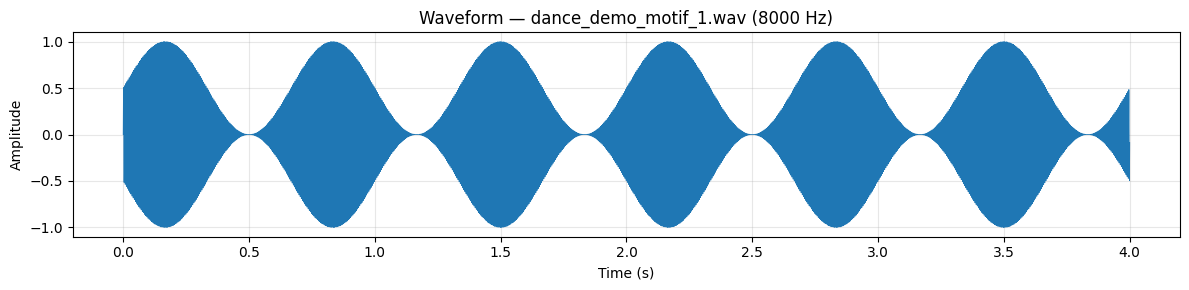

Controller JSON: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/worm_ingest/controller_demo.json size: 2506
Frames: 40
Sample control (first frame): [0.9573, 1.1892, 0.3612, -0.9903, 0.7166]

To re-run the full notebook with motif clustering (requires scikit-learn):

python3 -m pip install --user scikit-learn matplotlib
jupyter nbconvert --to notebook --execute PyANNOW/notebooks/06_pyannow_v2_patterns.ipynb --inplace


In [5]:
from pathlib import Path
import wave
import numpy as np
import json
import matplotlib.pyplot as plt
from IPython.display import Audio, display

archive_dir = OUTDIR / 'dance_archive'
ingest_dir = archive_dir / 'worm_ingest'

wav_files = sorted(archive_dir.glob('dance_demo_motif_*.wav'))
if not wav_files:
    print('No demo WAV found in', archive_dir)
else:
    wav_path = wav_files[-1]
    size = wav_path.stat().st_size
    print('Using WAV:', wav_path, 'size:', size)
    with wave.open(str(wav_path), 'rb') as w:
        fs = w.getframerate()
        nframes = w.getnframes()
        frames = w.readframes(nframes)
        audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32767.0
    t = np.arange(len(audio)) / float(fs)
    plt.figure(figsize=(12, 3))
    plt.plot(t, audio, lw=0.6)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Waveform — {wav_path.name} ({fs} Hz)')
    plt.tight_layout()
    plt.show()
    display(Audio(audio, rate=fs))

demo_json = ingest_dir / 'controller_demo.json'
if demo_json.exists():
    with open(demo_json, 'r') as f:
        dj = json.load(f)
    print('Controller JSON:', demo_json, 'size:', demo_json.stat().st_size)
    print('Frames:', len(dj.get('controls', [])))
    print('Sample control (first frame):', dj.get('controls', [None])[0])
else:
    print('No controller demo JSON found at', demo_json)

print('\nTo re-run the full notebook with motif clustering (requires scikit-learn):')
print('\npython3 -m pip install --user scikit-learn matplotlib')
print('jupyter nbconvert --to notebook --execute PyANNOW/notebooks/06_pyannow_v2_patterns.ipynb --inplace')


In [6]:
# ---- Controller scaffold: simple PINN/GNN fallback that uses linear mapping if JAX/Flax missing ----
import numpy as np
from pathlib import Path
import json

ingest_dir = OUTDIR / 'dance_archive' / 'worm_ingest'
weights_path = ingest_dir / 'worm_ingest_weights.npz'
if not weights_path.exists():
    print('Weights not found; run scripts/worm_ingestion_converter.py first.')
    raise SystemExit(1)
wp = np.load(weights_path)
W = wp['W']
print('Loaded linear weights shape:', W.shape)

# Lightweight controller wrapper
class SimpleController:
    def __init__(self, W):
        self.W = W
    def control_from_features(self, feat_z):
        x = np.concatenate([np.asarray(feat_z).ravel(), [1.0]])
        return x @ self.W  # (5,)
    def rollout(self, feat_z, duration_s=2.0, fs=50):
        # Repeat control vector at fs to create a timeline
        ctrl = self.control_from_features(feat_z)
        n = int(duration_s * fs)
        return np.tile(ctrl[None, :], (n, 1)), np.linspace(0, duration_s, n)

controller = SimpleController(W)
# Demo: use motif centroids loaded above if present, else zeros
try:
    feat_demo = feat  # from previous cell if executed
except NameError:
    # fallback: zeros matching W rows-1
    feat_demo = np.zeros(W.shape[0] - 1)
timeline, times_ctrl = controller.rollout(feat_demo, duration_s=4.0, fs=10)
print('Controller rollout shape:', timeline.shape)
print('Sample control (first frame):', dict(zip(['command_gain','motor_gain','muscle_gain','phase_shift','refractory_bias'], timeline[0].tolist())))

# If JAX/Flax are available you can replace SimpleController with a PINN that predicts
# control outputs while enforcing soft physical constraints. Placeholder below:
try:
    import jax, jax.numpy as jnp
    from flax import linen as nn
    print('JAX/Flax detected — PINN scaffold can be built here.')
    class PINNController(nn.Module):
        hidden: int = 64
        @nn.compact
        def __call__(self, x):
            x = nn.Dense(self.hidden)(x)
            x = nn.tanh(x)
            x = nn.Dense(5)(x)
            return x
    print('PINNController class defined (Flax).')
except Exception:
    print('JAX/Flax not available — using linear fallback controller.')

# Save a small demo JSON describing the controller outputs over time
import json

demo_out = {
    'times': times_ctrl.tolist(),
    'controls': timeline.round(4).tolist(),
}
demo_path = ingest_dir / 'controller_demo.json'
with open(demo_path, 'w') as f:
    json.dump(demo_out, f)
print('Saved controller demo JSON to', demo_path)


Loaded linear weights shape: (7, 5)
Controller rollout shape: (40, 5)
Sample control (first frame): {'command_gain': 0.3498385382135663, 'motor_gain': 0.3000000000000001, 'muscle_gain': 0.2500000000000001, 'phase_shift': -0.9925009652458313, 'refractory_bias': 1.1479423149403052}
JAX/Flax detected — PINN scaffold can be built here.
PINNController class defined (Flax).
Saved controller demo JSON to /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/worm_ingest/controller_demo.json


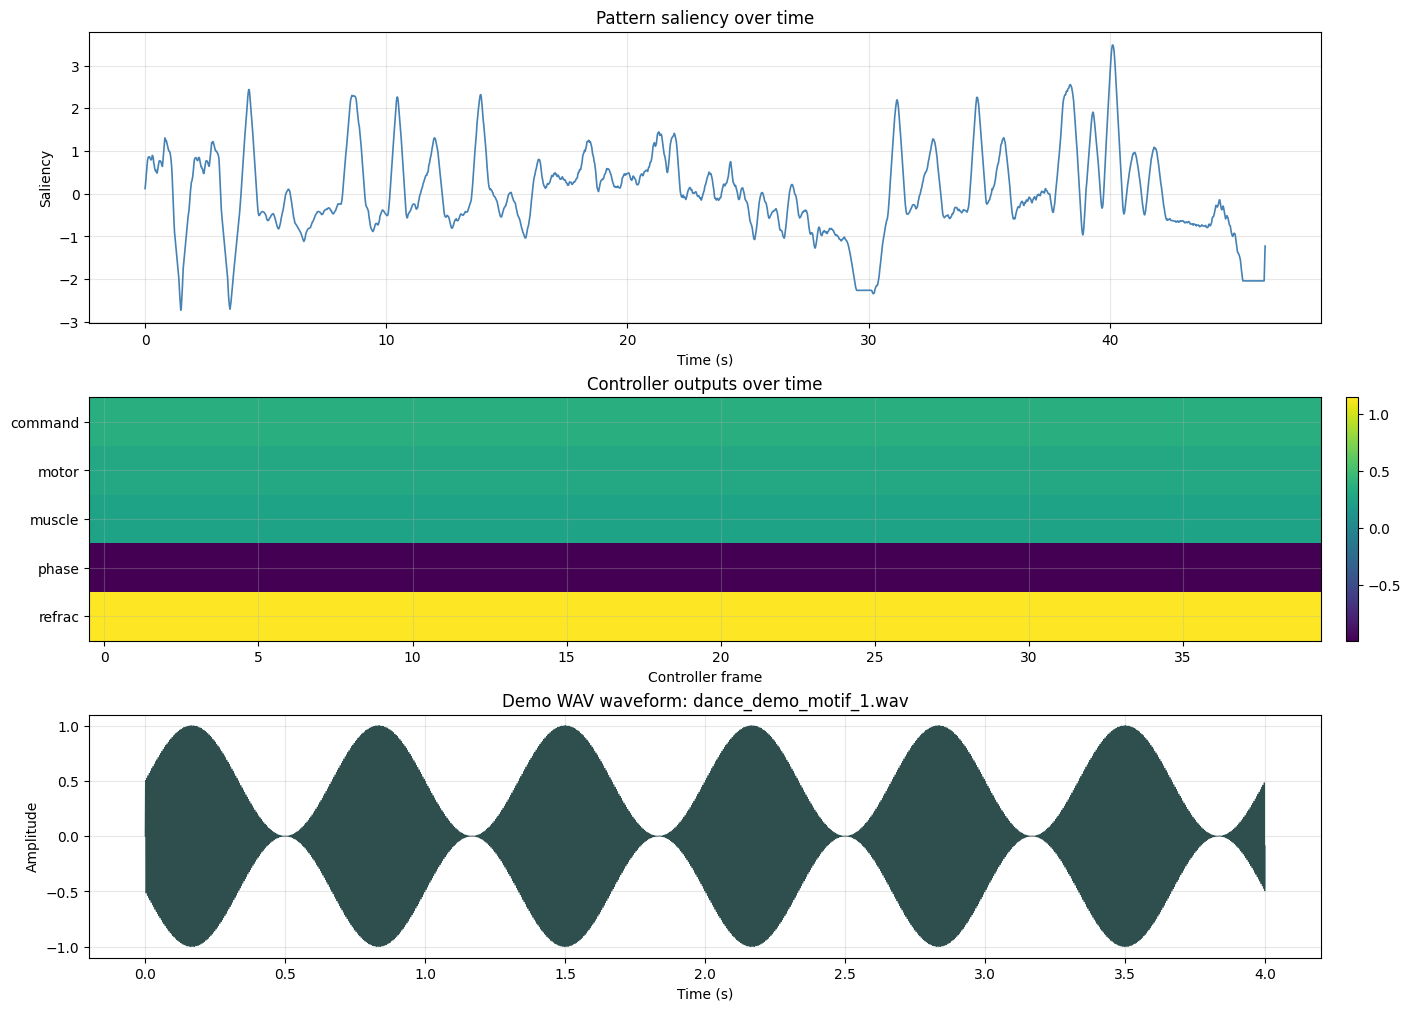

Visualized saliency points: 2323
Controller frames: 40
WAV file: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/dance_demo_motif_1.wav


In [9]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio
import wave

archive_dir = OUTDIR / 'dance_archive'
ingest_dir = archive_dir / 'worm_ingest'

# Prefer notebook variables when available, but fall back to disk artifacts.
if 'saliency_smooth' in globals() and 'summary_rows' in globals():
    sal_plot = np.asarray(saliency_smooth)
    t_sal = np.asarray(times[:len(sal_plot)]) if 'times' in globals() else np.arange(len(sal_plot)) * float(dt)
    spans = [(row['start_s'], row['end_s'], row['saliency']) for row in summary_rows]
else:
    bank_path = archive_dir / 'chopin_pattern_bank.npz'
    if not bank_path.exists():
        bank_path = archive_dir / 'chopin_pattern_bank_fallback.npz'
    bank = np.load(bank_path, allow_pickle=True)
    sal_plot = np.asarray(bank['saliency'])
    if 'times' in bank:
        t_sal = np.asarray(bank['times'])[:len(sal_plot)]
    else:
        t_sal = np.arange(len(sal_plot)) * float(dt)
    if 'window_bounds' in bank:
        wb = np.asarray(bank['window_bounds'])
        spans = [(float(t_sal[s]), float(t_sal[min(e - 1, len(t_sal) - 1)]), float(sal_plot[i])) for i, (s, e) in enumerate(wb[: min(len(wb), 12)])]
    else:
        spans = []

# Keep only overlays that live inside the visible saliency range.
t_max = float(t_sal.max()) if len(t_sal) else 0.0
visible_spans = [(s, e, score) for (s, e, score) in spans if s <= t_max]

controller_json = ingest_dir / 'controller_demo.json'
if controller_json.exists():
    with open(controller_json, 'r', encoding='utf-8') as f:
        ctrl = json.load(f)
    controls = np.asarray(ctrl.get('controls', []), dtype=float)
    ctrl_times = np.asarray(ctrl.get('times', []), dtype=float)
else:
    controls = np.asarray(timeline, dtype=float) if 'timeline' in globals() else np.empty((0, 5))
    ctrl_times = np.asarray(times_ctrl, dtype=float) if 'times_ctrl' in globals() else np.empty((0,))

# Pick a demo WAV for playback if available.
wav_files = sorted(archive_dir.glob('dance_demo_motif_*.wav'))
wav_path = wav_files[-1] if wav_files else None
if wav_path and wav_path.exists():
    with wave.open(str(wav_path), 'rb') as w:
        fs = w.getframerate()
        frames = w.readframes(w.getnframes())
    audio = np.frombuffer(frames, dtype=np.int16).astype(np.float32) / 32767.0
else:
    fs = None
    audio = None

fig = plt.figure(figsize=(14, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1.0, 1.0])

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_sal, sal_plot, color='steelblue', lw=1.2)
for i, (start_s, end_s, score) in enumerate(visible_spans[:8], 1):
    ax1.axvspan(start_s, min(end_s, t_max), color='crimson', alpha=0.08)
    ax1.text(start_s, score, str(i), fontsize=9, color='crimson', va='bottom')
ax1.set_title('Pattern saliency over time')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Saliency')

ax2 = fig.add_subplot(gs[1, 0])
if controls.size:
    im = ax2.imshow(controls.T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax2.set_yticks(range(5))
    ax2.set_yticklabels(['command', 'motor', 'muscle', 'phase', 'refrac'])
    ax2.set_xlabel('Controller frame')
    ax2.set_title('Controller outputs over time')
    fig.colorbar(im, ax=ax2, fraction=0.025, pad=0.02)
else:
    ax2.text(0.5, 0.5, 'Controller timeline not available', ha='center', va='center')
    ax2.set_axis_off()

ax3 = fig.add_subplot(gs[2, 0])
if audio is not None:
    t_audio = np.arange(len(audio)) / float(fs)
    ax3.plot(t_audio, audio, color='darkslategray', lw=0.6)
    ax3.set_title(f'Demo WAV waveform: {wav_path.name}')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Amplitude')
    display(Audio(audio, rate=fs))
else:
    ax3.text(0.5, 0.5, 'Demo WAV not available', ha='center', va='center')
    ax3.set_axis_off()

plt.show()

print('Visualized saliency points:', len(sal_plot))
print('Controller frames:', int(controls.shape[0]))
if wav_path is not None:
    print('WAV file:', wav_path)


## 5. What the machine learning is actually doing

This figure turns the notebook into a compact model audit:

- the saliency curve shows which musical windows the feature model considers most excitable,
- the PCA view shows how those windows cluster into motifs,
- the controller view shows how a motif is turned into worm control signals,
- the coefficient view shows the learned linear bridge from pattern features to control gains.

It is not just a prediction pipeline; it is a representation-learning pipeline with a learned, interpretable control map.


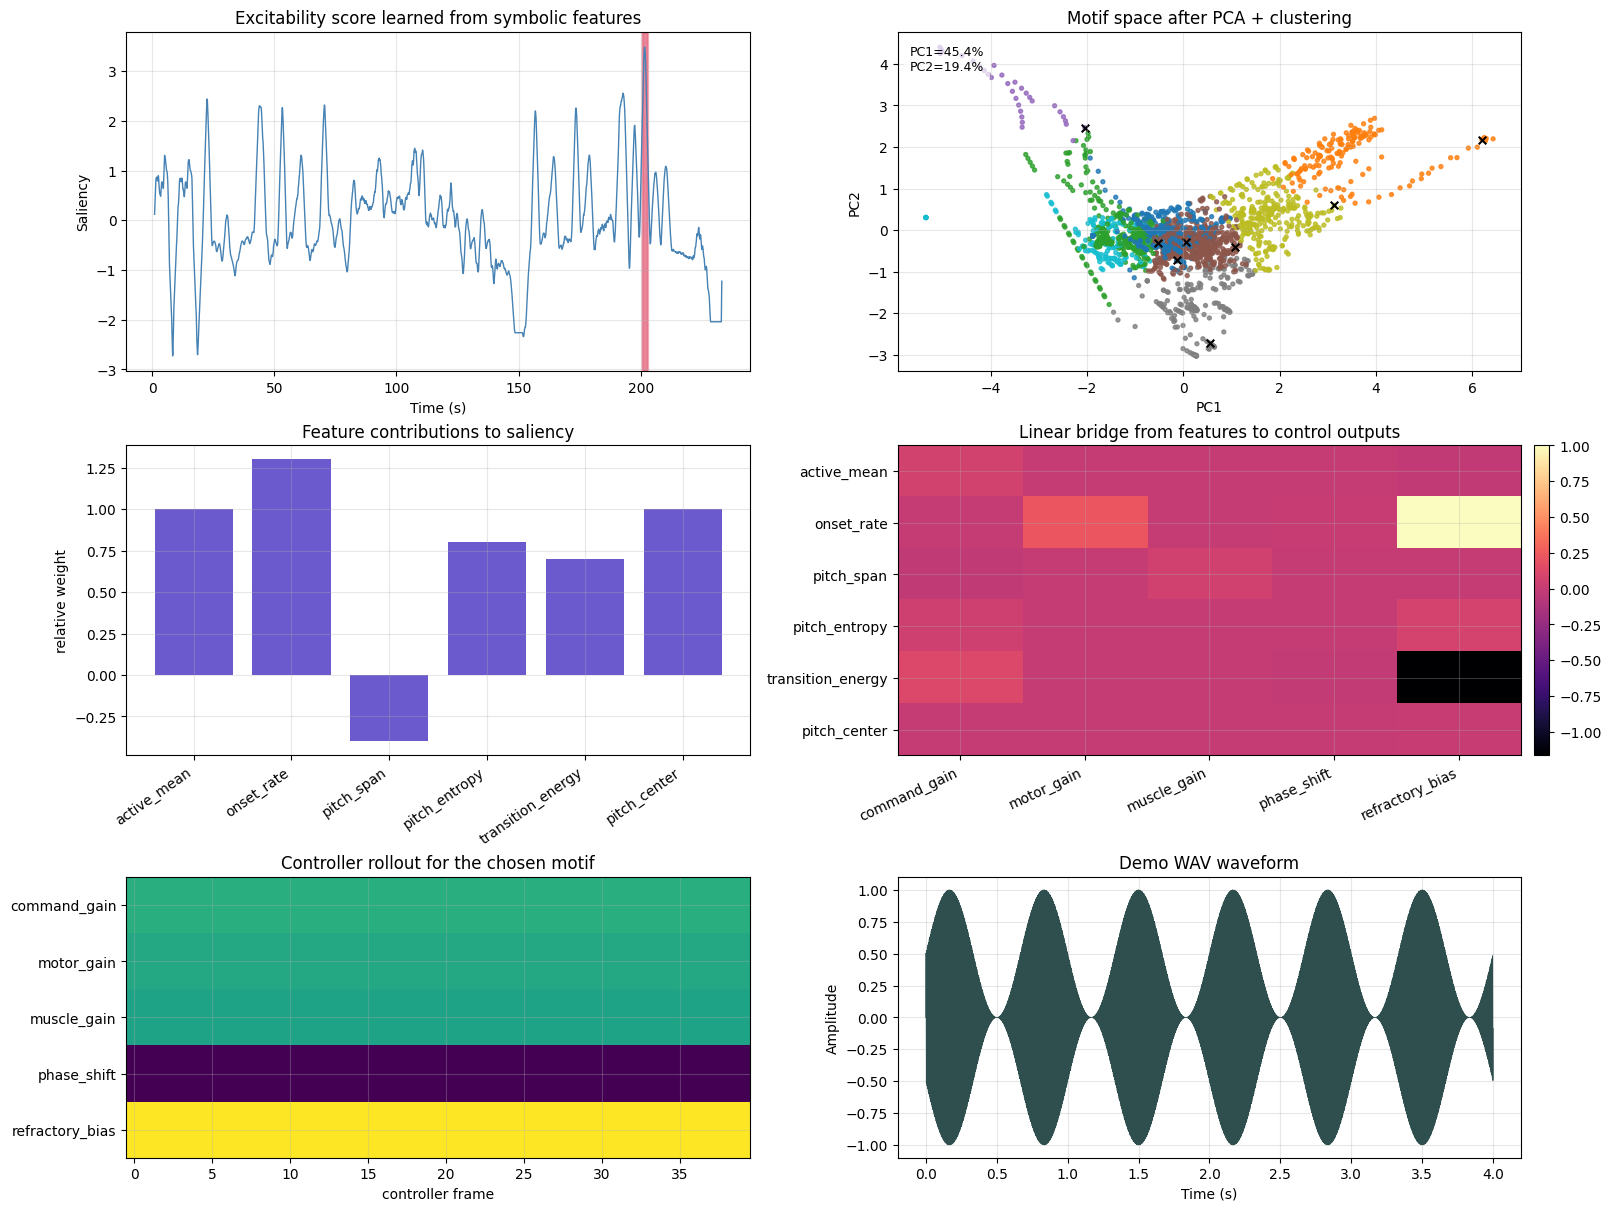

Chosen motif representative index: 880
Motif control vector: {'command_gain': 0.3749, 'motor_gain': 0.2143, 'muscle_gain': 0.2547, 'phase_shift': -0.9911, 'refractory_bias': 1.259}
Top motif label count: 588
Bank file: /Users/vghayoomie/git/wormuse/PyANNOW/notebooks/step_outputs/v2_patterns/dance_archive/chopin_pattern_bank.npz


In [11]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio
import wave

archive_dir = OUTDIR / 'dance_archive'
ingest_dir = archive_dir / 'worm_ingest'

bank_path = archive_dir / 'chopin_pattern_bank.npz'
if not bank_path.exists():
    bank_path = archive_dir / 'chopin_pattern_bank_fallback.npz'
bank = np.load(bank_path, allow_pickle=True)

# Shared data
Xw = np.asarray(bank['window_features_z']) if 'window_features_z' in bank else np.asarray(bank['window_features'], dtype=float)
if Xw.ndim != 2:
    Xw = np.asarray(Xw, dtype=float)
if 'window_features_z' not in bank:
    Xw = (Xw - Xw.mean(axis=0)) / (Xw.std(axis=0) + 1e-8)

sal_vec = np.asarray(bank['saliency']) if 'saliency' in bank else (1.3 * Xw[:, 1] + 1.0 * Xw[:, 0] + 0.8 * Xw[:, 3] + 0.7 * Xw[:, 4] - 0.4 * Xw[:, 2])
labels_vec = np.asarray(bank['motif_labels']) if 'motif_labels' in bank else np.zeros(len(Xw), dtype=int)
reps = np.asarray(bank['motif_representatives'], dtype=int) if 'motif_representatives' in bank else np.arange(min(8, len(Xw)))
centroids = np.asarray(bank['motif_centers']) if 'motif_centers' in bank else np.vstack([Xw[labels_vec == i].mean(axis=0) for i in np.unique(labels_vec)])

# Align the x-axis with the sliding-window coordinates, not the raw frame coordinates.
if 'window_bounds' in bank:
    wb = np.asarray(bank['window_bounds'])
    t_sal = 0.5 * (np.asarray(times[wb[:, 0]], dtype=float) + np.asarray(times[np.maximum(wb[:, 1] - 1, wb[:, 0])], dtype=float))
else:
    t_sal = np.asarray(times[: len(sal_vec)], dtype=float) if 'times' in globals() else np.arange(len(sal_vec), dtype=float)

# Controller map
W_local = np.load(ingest_dir / 'worm_ingest_weights.npz')['W']
control_names = ['command_gain', 'motor_gain', 'muscle_gain', 'phase_shift', 'refractory_bias']

# PCA projections for the motif space
coords_local = pca.transform(Xz) if 'pca' in globals() and 'Xz' in globals() else Xw[:, :2]
var_ratio = getattr(pca, 'explained_variance_ratio_', np.array([np.nan, np.nan, np.nan])) if 'pca' in globals() else np.array([np.nan, np.nan, np.nan])

# Choose representative motif for the control bridge
if 'summary_rows' in globals() and summary_rows:
    motif_choice = int(np.argmax([row['saliency'] for row in summary_rows]))
else:
    motif_choice = int(np.nanargmax(sal_vec))
if 'motif_reps' in globals() and motif_reps:
    rep_idx = int(motif_reps[motif_choice % len(motif_reps)])
else:
    rep_idx = int(reps[motif_choice % len(reps)])
feat_rep = Xw[rep_idx]
x_design = np.concatenate([feat_rep, [1.0]])
ctrl_vec = x_design @ W_local

# Contributions of each feature to saliency and control.
saliency_weights = np.array([1.0, 1.3, -0.4, 0.8, 0.7, 1.0])
saliency_weights = saliency_weights[: Xw.shape[1]]
saliency_contrib = saliency_weights * np.nanstd(Xw, axis=0)
ctrl_weights = W_local[:-1, :]

fig = plt.figure(figsize=(16, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 2, height_ratios=[1.15, 1.05, 0.95])

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_sal, sal_vec, color='steelblue', lw=1.0)
if 'summary_rows' in globals():
    for row in summary_rows[:8]:
        ax1.axvspan(row['start_s'], row['end_s'], color='crimson', alpha=0.08)
ax1.set_title('Excitability score learned from symbolic features')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Saliency')

ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(coords_local[:, 0], coords_local[:, 1], c=labels_vec, cmap='tab10', s=8, alpha=0.8)
if len(reps):
    ax2.scatter(coords_local[reps, 0], coords_local[reps, 1], c='black', s=30, marker='x', label='motif reps')
ax2.set_title('Motif space after PCA + clustering')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
if np.isfinite(var_ratio[0]):
    ax2.text(0.02, 0.96, f'PC1={var_ratio[0]*100:.1f}%\nPC2={var_ratio[1]*100:.1f}%', transform=ax2.transAxes, va='top', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(np.arange(len(feature_names)), saliency_contrib, color='slateblue')
ax3.set_xticks(np.arange(len(feature_names)))
ax3.set_xticklabels(feature_names, rotation=35, ha='right')
ax3.set_title('Feature contributions to saliency')
ax3.set_ylabel('relative weight')

ax4 = fig.add_subplot(gs[1, 1])
heat = ax4.imshow(ctrl_weights, aspect='auto', cmap='magma', interpolation='nearest')
ax4.set_yticks(np.arange(len(feature_names)))
ax4.set_yticklabels(feature_names)
ax4.set_xticks(np.arange(len(control_names)))
ax4.set_xticklabels(control_names, rotation=25, ha='right')
ax4.set_title('Linear bridge from features to control outputs')
fig.colorbar(heat, ax=ax4, fraction=0.03, pad=0.02)

ax5 = fig.add_subplot(gs[2, 0])
if 'controls' in globals() and len(controls):
    ax5.imshow(np.asarray(controls).T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax5.set_yticks(np.arange(len(control_names)))
    ax5.set_yticklabels(control_names)
    ax5.set_xlabel('controller frame')
    ax5.set_title('Controller rollout for the chosen motif')
else:
    ax5.text(0.5, 0.5, 'Controller rollout not available', ha='center', va='center')
    ax5.set_axis_off()

ax6 = fig.add_subplot(gs[2, 1])
if 'audio' in globals() and audio is not None:
    t_audio = np.arange(len(audio)) / float(fs)
    ax6.plot(t_audio, audio, color='darkslategray', lw=0.6)
    ax6.set_title('Demo WAV waveform')
    ax6.set_xlabel('Time (s)')
    ax6.set_ylabel('Amplitude')
    display(Audio(audio, rate=fs))
else:
    ax6.text(0.5, 0.5, 'Demo audio not available', ha='center', va='center')
    ax6.set_axis_off()

plt.show()

print('Chosen motif representative index:', rep_idx)
print('Motif control vector:', dict(zip(control_names, ctrl_vec.round(4).tolist())))
print('Top motif label count:', int(np.bincount(labels_vec).max()) if len(labels_vec) else 0)
print('Bank file:', bank_path)


## 6. Architecture view

This final view summarizes the full machine-learning stack as a flow of representations: raw score windows, standardized features, motif clustering, controller mapping, and the resulting worm-control outputs.


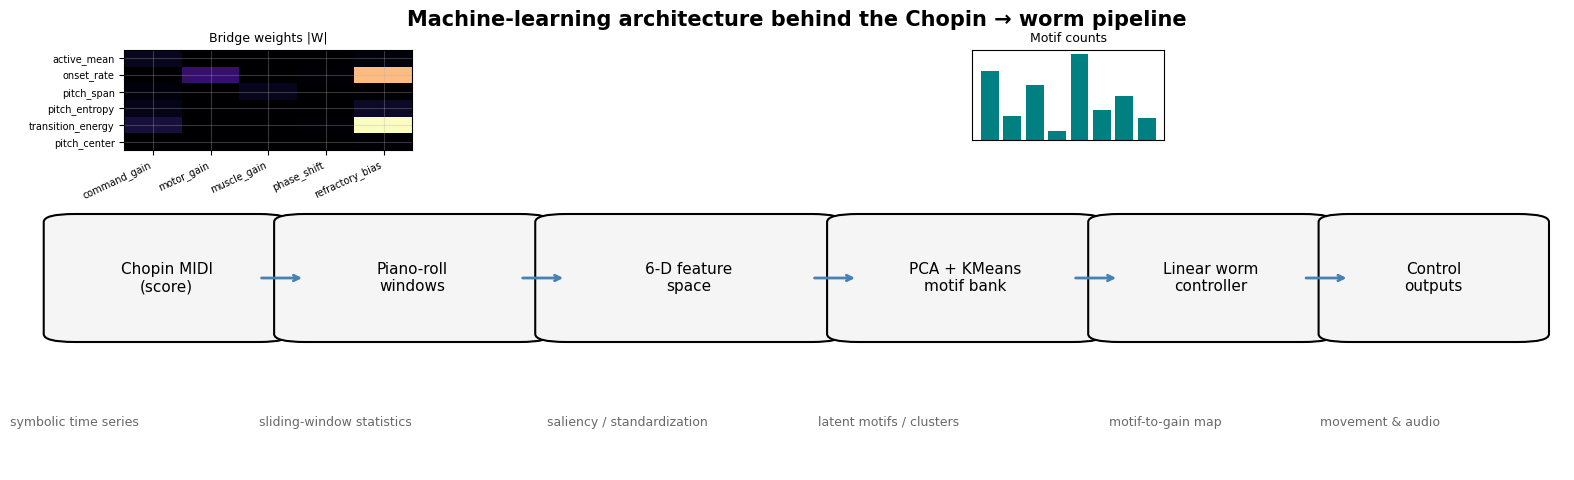

Feature dimension: 6
Motifs discovered: 8
Controller matrix shape: (7, 5)
Largest motif cluster: 588


In [13]:
import matplotlib.patches as patches
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Machine-learning architecture behind the Chopin → worm pipeline', fontsize=15, weight='bold', y=0.98)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

boxes = [
    (0.03, 0.34, 0.12, 0.28, 'Chopin MIDI\n(score)'),
    (0.18, 0.34, 0.14, 0.28, 'Piano-roll\nwindows'),
    (0.35, 0.34, 0.16, 0.28, '6-D feature\nspace'),
    (0.54, 0.34, 0.14, 0.28, 'PCA + KMeans\nmotif bank'),
    (0.71, 0.34, 0.12, 0.28, 'Linear worm\ncontroller'),
    (0.86, 0.34, 0.11, 0.28, 'Control\noutputs'),
]

for x, y, w, h, label in boxes:
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.5,
        edgecolor='black',
        facecolor='#f5f5f5',
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=11)

# arrows between boxes
for left, right in zip(boxes[:-1], boxes[1:]):
    x1 = left[0] + left[2]
    y1 = left[1] + left[3] / 2
    x2 = right[0]
    y2 = right[1] + right[3] / 2
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=2, color='steelblue'))

# callouts showing what each stage computes
callouts = [
    (0.03, 0.12, 'symbolic time series'),
    (0.20, 0.12, 'sliding-window statistics'),
    (0.39, 0.12, 'saliency / standardization'),
    (0.56, 0.12, 'latent motifs / clusters'),
    (0.74, 0.12, 'motif-to-gain map'),
    (0.88, 0.12, 'movement & audio'),
]
for x, y, text in callouts:
    ax.text(x, y, text, ha='center', va='center', fontsize=9, color='dimgray')

# tiny inset: controller coefficients
inset = fig.add_axes([0.08, 0.70, 0.18, 0.20])
coeff = np.abs(np.asarray(W_local[:-1, :]))
inset.imshow(coeff, aspect='auto', cmap='magma')
inset.set_xticks(np.arange(coeff.shape[1]))
inset.set_xticklabels(control_names, rotation=25, ha='right', fontsize=7)
inset.set_yticks(np.arange(len(feature_names)))
inset.set_yticklabels(feature_names, fontsize=7)
inset.set_title('Bridge weights |W|', fontsize=9)

# tiny inset: motif cluster cardinalities
inset2 = fig.add_axes([0.61, 0.72, 0.12, 0.18])
counts = np.bincount(labels_vec) if len(labels_vec) else np.array([])
if len(counts):
    inset2.bar(np.arange(len(counts)), counts, color='teal')
    inset2.set_title('Motif counts', fontsize=9)
    inset2.set_xticks([])
    inset2.set_yticks([])
else:
    inset2.text(0.5, 0.5, 'no motifs', ha='center', va='center')
    inset2.set_axis_off()

plt.subplots_adjust(top=0.86, bottom=0.06, left=0.02, right=0.98)
plt.show()

print('Feature dimension:', Xw.shape[1])
print('Motifs discovered:', int(len(np.unique(labels_vec))))
print('Controller matrix shape:', W_local.shape)
print('Largest motif cluster:', int(np.max(np.bincount(labels_vec))) if len(labels_vec) else 0)
